In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from centrex_trajectories import (
    Coordinates,
    Gravity,
    PropagationOptions,
    ODEVectorizedOptions,
    Velocities,
    propagate_trajectories,
)
from centrex_trajectories.beamline_objects import (
    Bore,
    ElectrostaticQuadrupoleLens,
)
from centrex_trajectories.particles import Particle, TlF
from centrex_trajectories.random_generation import (
    generate_random_coordinates_uniform_circle,
)
from centrex_trajectories.data_structures import Trajectories

In [2]:
plt.rcParams.update({"font.size": 14})


In [3]:
rng = np.random.default_rng(seed=42)  # For reproducibility

In [4]:
particle = TlF()
gravity = Gravity(0, -9.81 * particle.mass, 0)
options = PropagationOptions(verbose=False, n_cores=8)
L = 0.6
R = 1.75 * 25.4e-3 / 2
n_trajectories = 300_000
V_eql = 30_000

In [5]:
from centrex_trajectories.propagation_options import PropagationType

origin = generate_random_coordinates_uniform_circle(
    radius=R, number=n_trajectories, x=0, y=0, z=-1e-2, rng=rng
)
velocities = Velocities(
    rng.uniform(-3, 3, n_trajectories),
    rng.uniform(-3, 3, n_trajectories),
    rng.uniform(100, 250, n_trajectories),
)

eql = ElectrostaticQuadrupoleLens(
    name="Electrostatic Lens",
    objects=[],
    start=0,
    stop=L,
    V=V_eql,
    R=R,
    save_collisions=True,
)

In [6]:
import numpy.typing as npt


def extract_final_state(
    trajectories: Trajectories,
) -> dict[str, npt.NDArray[np.float64]]:
    """
    Extract final [x, y, z, vx, vy, vz] arrays from a Trajectories object.

    Returns:
        dict[str, np.ndarray]: {
            "x":  (n_traj,),
            "y":  (n_traj,),
            "z":  (n_traj,),
            "vx": (n_traj,),
            "vy": (n_traj,),
            "vz": (n_traj,),
        }
    """
    fields = ("x", "y", "z", "vx", "vy", "vz")

    return {
        f: np.array([getattr(traj, f)[-1] for traj in trajectories.values()])
        for f in fields
    }

In [7]:
eql.propagation_type = PropagationType.ode

sections = [eql]
section_data_ode, trajectories_ode = propagate_trajectories(
    sections,
    origin,
    velocities,
    particle,
    force=gravity,
    options=options,
)

final_state_ode = extract_final_state(trajectories_ode)

In [8]:
eql.propagation_type = PropagationType.ode_vectorized

final_states = []
for steps in tqdm([5, 10, 25]):
    ode_vectorized_options = ODEVectorizedOptions(
        n_steps=steps,
        n_save=1,
    )
    propagation_options = PropagationOptions(
        verbose=False,
        n_cores=8,
        section_options={eql.name: ode_vectorized_options},
    )
    sections = [eql]
    section_data_ode_vectorized, trajectories_ode_vectorized = propagate_trajectories(
        sections,
        origin,
        velocities,
        particle,
        force=gravity,
        options=propagation_options,
    )

    final_state_ode_vectorized = extract_final_state(trajectories_ode_vectorized)
    final_states.append((steps, final_state_ode_vectorized))

100%|██████████| 3/3 [00:16<00:00,  5.47s/it]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from typing import Iterable, Tuple, Dict


def plot_ridgeline_x_difference(
    final_states: Iterable[Tuple[int, Dict[str, np.ndarray]]],
    final_state_ode: Dict[str, np.ndarray],
    n_points: int = 500,
    vertical_scale: float = 1.0,
    field: str = "x",
):
    """
    Ridgeline plot of the KDE of x_ode - x_ode_vectorized for each (steps, state) entry.

    The KDE domain is restricted to ±4σ around the global mean.
    """
    # ------------------------------------------------------------------
    # Collect all differences to compute global +-4σ limits
    # ------------------------------------------------------------------
    all_y = []
    for _, final_state_ode_vectorized in final_states:
        y = final_state_ode[field] - final_state_ode_vectorized[field]
        all_y.append(y)

    all_y_flat = np.concatenate(all_y)
    mu = np.mean(all_y_flat)
    sigma = np.std(all_y_flat)

    # limit evaluation range to +/- 4 sigma
    x_min = mu - 4 * sigma
    x_max = mu + 4 * sigma
    xs = np.linspace(x_min, x_max, n_points)

    # ------------------------------------------------------------------
    # Make the ridgeline plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))

    # Sort by number of steps so ridges appear nicely ordered
    sorted_states = sorted(final_states, key=lambda t: t[0])

    for idx, (steps, final_state_ode_vectorized) in enumerate(sorted_states):
        y = final_state_ode[field] - final_state_ode_vectorized[field]
        kde = gaussian_kde(y)

        density = kde(xs)

        # Normalize each ridge height for separation
        density_scaled = density / density.max() * vertical_scale

        baseline = idx  # vertical offset
        ax.fill_between(
            xs,
            baseline,
            baseline + density_scaled,
            alpha=0.6,
        )
        ax.plot(xs, baseline + density_scaled, lw=1)

    # Labeling
    step_labels = [str(steps) for steps, _ in sorted_states]
    ax.set_yticks(range(len(step_labels)))
    ax.set_yticklabels(step_labels)

    if "v" in field:
        unit = "[m/s]"
    else:
        unit = "[m]"
    ax.set_xlabel(f"{field}_ode - {field}_ode_vectorized {unit}")
    ax.set_ylabel("steps")
    ax.set_xlim(x_min, x_max)
    ax.grid(axis="x", alpha=0.3)

    fig.tight_layout()
    return fig, ax


(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='vx_ode - vx_ode_vectorized [m/s]', ylabel='steps'>)

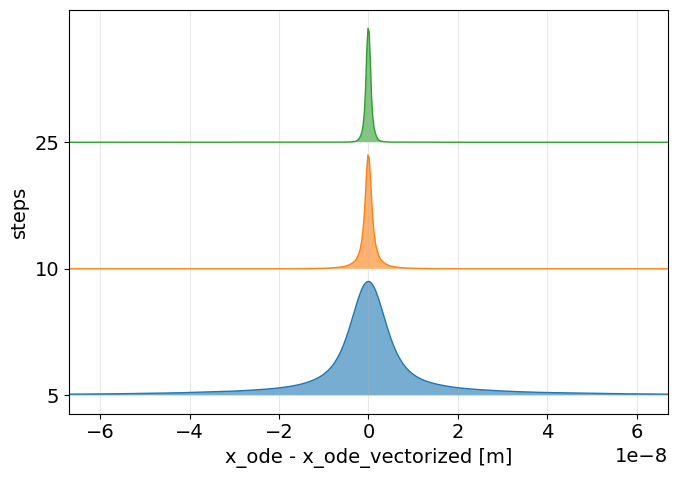

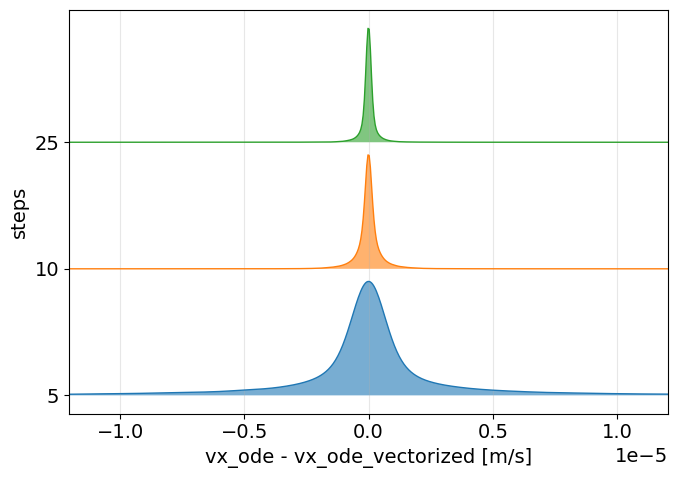

In [10]:
plot_ridgeline_x_difference(
    final_states, final_state_ode, vertical_scale=0.9, field="x"
)
plot_ridgeline_x_difference(
    final_states, final_state_ode, vertical_scale=0.9, field="vx"
)

In [11]:
eql = ElectrostaticQuadrupoleLens(
    name="Electrostatic Lens",
    objects=[Bore(x=0, y=0, z=0, length=L, radius=R)],
    start=0,
    stop=L,
    V=V_eql,
    R=R,
    save_collisions=True,
)
eql.propagation_type = PropagationType.ode

sections = [eql]
section_data_ode, trajectories_ode = propagate_trajectories(
    sections,
    origin,
    velocities,
    particle,
    force=gravity,
    options=options,
)

final_state_ode = extract_final_state(trajectories_ode)

In [12]:
eql.propagation_type = PropagationType.ode_vectorized

ode_vectorized_options = ODEVectorizedOptions(
    n_steps=10,
    n_save=10,
)
propagation_options = PropagationOptions(
    verbose=False,
    n_cores=8,
    section_options={eql.name: ode_vectorized_options},
)
sections = [eql]
section_data_ode_vectorized, trajectories_ode_vectorized = propagate_trajectories(
    sections,
    origin,
    velocities,
    particle,
    force=gravity,
    options=propagation_options,
)

In [22]:
percent_diff = (len(trajectories_ode_vectorized) - len(trajectories_ode)) / len(
    trajectories_ode
)
print(f"Percentage difference in number of trajectories: {abs(percent_diff):.2%}")

Percentage difference in number of trajectories: 0.05%


In [21]:
only_in_ode = [
    int(val)
    for val in set(trajectories_ode.keys()) - set(trajectories_ode_vectorized.keys())
]
only_in_vectorized = [
    int(val)
    for val in set(trajectories_ode_vectorized.keys()) - set(trajectories_ode.keys())
]
print(f"Trajectories only in ODE: {len(only_in_ode)}")
print(f"Trajectories only in ODE Vectorized: {len(only_in_vectorized)}")

Trajectories only in ODE: 139
Trajectories only in ODE Vectorized: 2


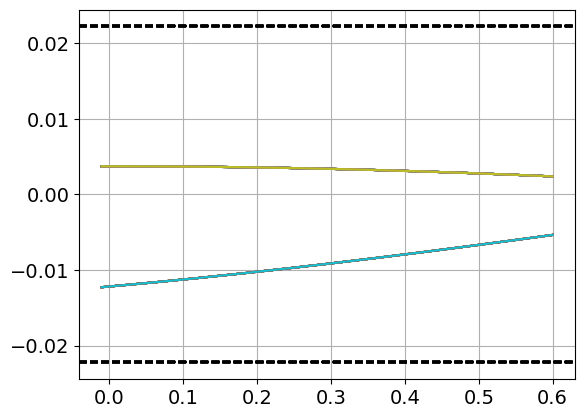

In [15]:
fig, ax = plt.subplots()
for _ in range(50):
    idt = rng.choice(only_in_vectorized)
    try:
        ax.plot(trajectories_ode[idt].z, trajectories_ode[idt].x, label="ODE")
    except KeyError:
        pass
    ax.plot(
        trajectories_ode_vectorized[idt].z,
        trajectories_ode_vectorized[idt].x,
        label="ODE Vectorized",
    )
    ax.axhline(-R, color="k", ls="--")
    ax.axhline(R, color="k", ls="--")
ax.grid()

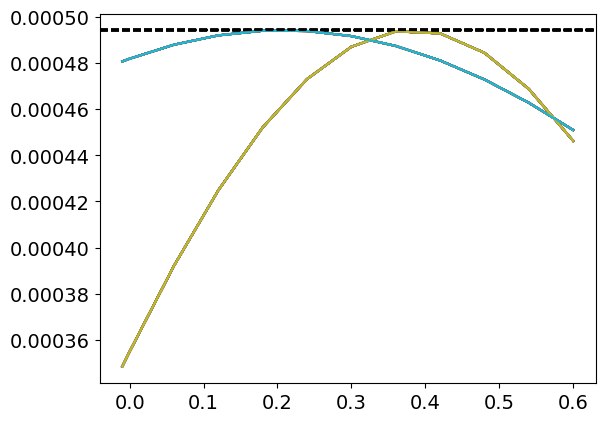

In [16]:
fig, ax = plt.subplots()
for _ in range(50):
    idt = rng.choice(only_in_vectorized)
    try:
        ax.plot(
            trajectories_ode[idt].z,
            trajectories_ode[idt].x ** 2 + trajectories_ode[idt].y ** 2,
            label="ODE",
        )
    except KeyError:
        pass
    try:
        ax.plot(
            trajectories_ode_vectorized[idt].z,
            trajectories_ode_vectorized[idt].x ** 2
            + trajectories_ode_vectorized[idt].y ** 2,
            label="ODE Vectorized",
        )
    except KeyError:
        pass
    ax.axhline(R**2, color="k", ls="--")

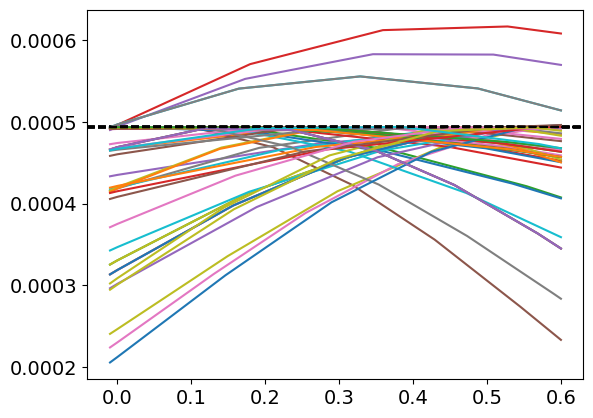

In [17]:
fig, ax = plt.subplots()
for _ in range(50):
    idt = rng.choice(only_in_ode)
    try:
        ax.plot(
            trajectories_ode[idt].z,
            trajectories_ode[idt].x ** 2 + trajectories_ode[idt].y ** 2,
            label="ODE",
        )
    except KeyError:
        pass
    try:
        ax.plot(
            trajectories_ode_vectorized[idt].z,
            trajectories_ode_vectorized[idt].x ** 2
            + trajectories_ode_vectorized[idt].y ** 2,
            label="ODE Vectorized",
        )
    except KeyError:
        pass
    ax.axhline(R**2, color="k", ls="--")

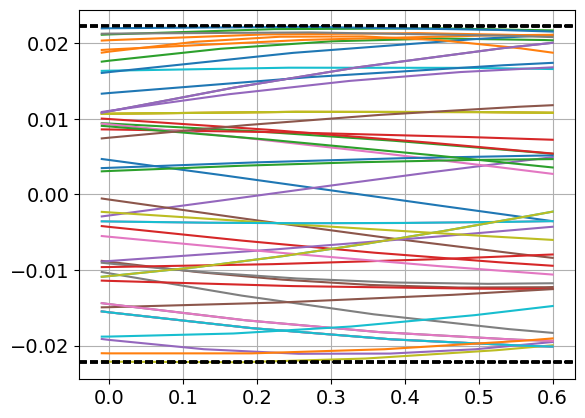

In [18]:
fig, ax = plt.subplots()
for _ in range(50):
    idt = rng.choice(only_in_ode)
    try:
        ax.plot(trajectories_ode[idt].z, trajectories_ode[idt].x, label="ODE")
    except KeyError:
        pass
    try:
        ax.plot(
            trajectories_ode_vectorized[idt].z,
            trajectories_ode_vectorized[idt].x,
            label="ODE Vectorized",
        )
    except KeyError:
        pass
    ax.axhline(-R, color="k", ls="--")
    ax.axhline(R, color="k", ls="--")
ax.grid()

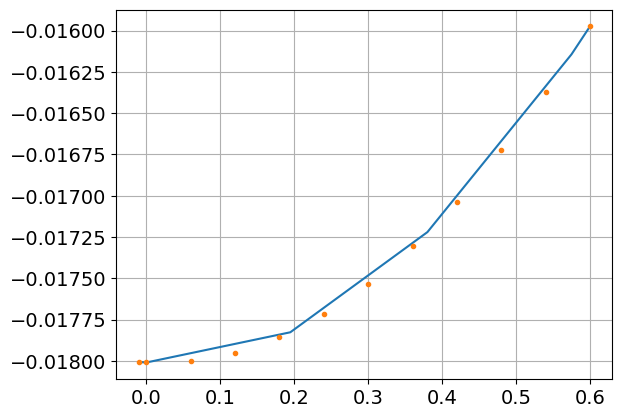

In [19]:
idt = rng.choice(list(trajectories_ode_vectorized.keys()))
fig, ax = plt.subplots()
try:
    ax.plot(trajectories_ode[idt].z, trajectories_ode[idt].x, label="ODE")
except KeyError:
    pass
ax.plot(
    trajectories_ode_vectorized[idt].z,
    trajectories_ode_vectorized[idt].x,
    ".",
    label="ODE Vectorized",
)
ax.grid()

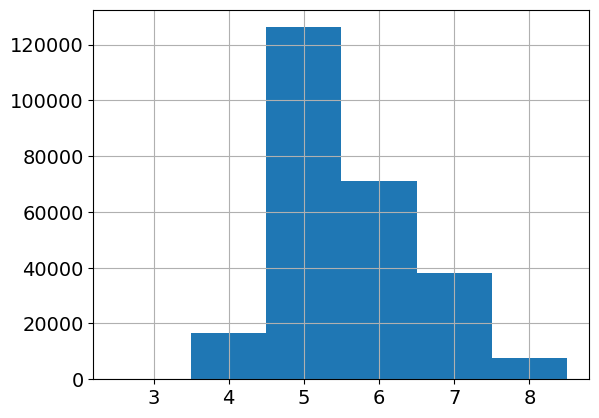

In [20]:
lengths = []
for traj in trajectories_ode.values():
    lengths.append(len(traj))

unique_l = np.unique(lengths)
bins = np.arange(min(lengths), max(lengths) + 2) - 0.5

fig, ax = plt.subplots()
ax.hist(lengths, bins=bins)
ax.grid()